**Understanding Individual Hospital Quality**

Q1 — What does a hospital's overall quality profile look like across all dimensions?
Definition: quality profile = a hospital's combined scores across safety, experience, spending, and readmissions — not just one number.
This is the core output of your analyzer. For any given hospital you want to see all five lenses at once. Does a hospital that scores well on patient experience also score well clinically? Or are these unrelated? 
 
Q2 — How aligned is the CMS star rating with actual clinical outcomes?
Definition: star rating = CMS's 1-5 summary score, computed from a weighted formula across multiple measure groups.
Sometimes a hospital has a 4-star rating but a mortality rate worse than the national average. Understanding where the star rating misleads or oversimplifies is analytically valuable.



## What does a hospital's overall quality profile look like across all dimensions?
### Quality profile = combine(+) safety + patient experience + hospital spending + readmission 

Safety --> complications_cleaned  
           associated_infections_cleaned
Patient Experience --> hcahps_cleaned
Hospital spending --> medicare_cleaned
Readmissions --> readmissions_cleaned

#### Combination : 
##### Safety
Addition of complications_cleaned score AND associated_infections_cleaned score per each hospital
1- count of "better than national rate" flags in complications_cleaned
2- count of "better than national benchmark" flags in associated_infections_cleaned
combined: The more flags = The best hospital

##### Patient Experience
average of hcahps_linear_* columns only
higher = better

##### Hospital Spending 
med_complete_episode__total
compare to national average: above 1 = red flag

##### Readmissions 
average of readm_ratio_* columns
above 1.0 = red flag, higher above 1.0 = worse

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

In [2]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list = ['comp_flag_comp_hip_knee', 'comp_flag_hybrid_hwm', 'comp_flag_mort_30_ami', 
             'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd', 'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 
             'comp_flag_mort_30_stk', 'comp_flag_psi_03', 'comp_flag_psi_04', 'comp_flag_psi_06', 'comp_flag_psi_08', 
             'comp_flag_psi_09', 'comp_flag_psi_10', 'comp_flag_psi_11', 'comp_flag_psi_12', 'comp_flag_psi_13', 
             'comp_flag_psi_14', 'comp_flag_psi_15', 'comp_flag_psi_90']

better_counts = (
    complications[flag_list]
    .apply(lambda row: (row == 'Better Than the National Rate').sum(), axis=1)
)

better_df_complications = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'comp_better_flags': better_counts
})

best_in_complications = (
    better_df_complications
    .sort_values('comp_better_flags', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

best_in_complications[['facility_id', 'facility_name', 'state', 'hospital_type', 'comp_better_flags']]


,facility_id,facility_name,state,hospital_type,comp_better_flags
0,330101,NEW YORK-PRESBYTERIAN HOSPITAL,NY,Acute Care Hospitals,14
1,330214,NYU LANGONE HOSPITALS,NY,Acute Care Hospitals,12
2,140010,NORTHSHORE UNIVERSITY HEALTHSYSTEM - EVANSTON ...,IL,Acute Care Hospitals,11
3,240010,MAYO CLINIC HOSPITAL ROCHESTER,MN,Acute Care Hospitals,9
4,220071,MASSACHUSETTS GENERAL HOSPITAL,MA,Acute Care Hospitals,8
5,390111,HOSPITAL OF UNIV OF PENNSYLVANIA,PA,Acute Care Hospitals,8
6,360180,CLEVELAND CLINIC,OH,Acute Care Hospitals,8
7,100151,MAYO CLINIC,FL,Acute Care Hospitals,8
8,450358,HOUSTON METHODIST HOSPITAL,TX,Acute Care Hospitals,8
9,310001,HACKENSACK UNIVERSITY MEDICAL CENTER,NJ,Acute Care Hospitals,7


In [3]:
infections = pd.read_csv('associated_infections_cleaned.csv')

flag_list1 = ['infection_flag_hai_1_sir',
    'infection_flag_hai_2_sir',
    'infection_flag_hai_3_sir',
    'infection_flag_hai_4_sir',
    'infection_flag_hai_5_sir',
    'infection_flag_hai_6_sir']

better_counts = (
    infections[flag_list1]
    .apply(lambda row: (row == 'Better than the National Benchmark').sum(), axis=1)
)
better_df_infections = pd.DataFrame({
    'facility_id': infections['facility_id'],
    'hai_better_flags': better_counts
})

best_in_infections = (
    better_df_infections
    .sort_values('hai_better_flags', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

best_in_infections[['facility_id', 'facility_name', 'state', 'hospital_type', 'hai_better_flags']]


,facility_id,facility_name,state,hospital_type,hai_better_flags
0,440161,TRISTAR CENTENNIAL MEDICAL CENTER,TN,Acute Care Hospitals,6
1,100007,ADVENTHEALTH ORLANDO,FL,Acute Care Hospitals,6
2,260138,ST LUKES HOSPITAL OF KANSAS CITY,MO,Acute Care Hospitals,5
3,450021,BAYLOR UNIVERSITY MEDICAL CENTER,TX,Acute Care Hospitals,5
4,030036,CHANDLER REGIONAL MEDICAL CENTER,AZ,Acute Care Hospitals,5
5,030023,FLAGSTAFF MEDICAL CENTER,AZ,Acute Care Hospitals,5
6,440049,METHODIST HOSPITALS OF MEMPHIS,TN,Acute Care Hospitals,5
7,060031,CENTURA HEALTH-PENROSE ST FRANCIS HEALTH SERVICES,CO,Acute Care Hospitals,5
8,330195,LONG ISLAND JEWISH MEDICAL CENTER,NY,Acute Care Hospitals,5
9,450135,TEXAS HEALTH HARRIS METHODIST FORT WORTH,TX,Acute Care Hospitals,5


In [4]:
patient_experience = pd.read_csv('hcahps_cleaned.csv')
## print(patient_experience.filter(like='hcahps_linear').head(3).T)

flag_list2 = [
    'hcahps_linear_h_clean_linear_score',
    'hcahps_linear_h_comp_1_linear_score',
    'hcahps_linear_h_comp_2_linear_score',
    'hcahps_linear_h_comp_5_linear_score',
    'hcahps_linear_h_comp_6_linear_score',
    'hcahps_linear_h_hsp_rating_linear_score',
    'hcahps_linear_h_quiet_linear_score',
    'hcahps_linear_h_recmnd_linear_score'
]

complete_reporters = patient_experience.dropna(subset=flag_list2)
print(f"Hospitals with complete experience data: {len(complete_reporters)} out of {len(patient_experience)}")

best_score = (
    complete_reporters[flag_list2].apply(lambda x: x.mean(), axis=1)
)

better_df_experience = pd.DataFrame({
    'facility_id': complete_reporters['facility_id'],
    'patient_exp_score': best_score
})
best_in_patient_experience = (
    better_df_experience
    .sort_values('patient_exp_score', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 
                      'hospital_type', 'hospital_overall_rating']],
        on='facility_id',
        how='left'
    )
)

best_in_patient_experience[[
    'facility_id', 'facility_name', 'state', 
    'hospital_type', 'hospital_overall_rating', 'patient_exp_score'
]]

Hospitals with complete experience data: 3183 out of 3961


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,patient_exp_score
0,440007,UNITY MEDICAL CENTER,TN,Acute Care Hospitals,NaN,97.250
1,190184,CITIZENS MEDICAL CENTER,LA,Acute Care Hospitals,3.0,96.375
2,451367,UT HEALTH EAST TEXAS PITTSBURG HOSPITAL,TX,Critical Access Hospitals,2.0,94.875
3,390323,ADVANCED SURGICAL HOSPITAL,PA,Acute Care Hospitals,NaN,94.875
4,390324,PHYSICIANS CARE SURGICAL HOSPITAL,PA,Acute Care Hospitals,NaN,94.750
5,141302,MIDWEST MEDICAL CENTER,IL,Critical Access Hospitals,NaN,94.625
6,520194,ORTHOPAEDIC HOSPITAL OF WISCONSIN,WI,Acute Care Hospitals,NaN,94.625
7,111320,HIGGINS GENERAL HOSPITAL,GA,Critical Access Hospitals,NaN,94.500
8,041311,HOWARD MEMORIAL HOSPITAL,AR,Critical Access Hospitals,NaN,94.500
9,181329,CHI SAINT JOSEPH BEREA NF,KY,Critical Access Hospitals,NaN,94.375


In [5]:
hosp_spending = pd.read_csv('medicare_cleaned.csv')

hosp_spending['facility_id'] = hosp_spending['facility_id'].astype(str).str.zfill(6)
general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)

national_avg_spending = hosp_spending['med_complete_episode__total'].mean()

spending_scores = pd.DataFrame({
    'facility_id': hosp_spending['facility_id'],
    'spending_total': hosp_spending['med_complete_episode__total'],
    'spending_ratio': hosp_spending['med_complete_episode__total'] / national_avg_spending
})

best_in_spending = (
    spending_scores
    .sort_values('spending_ratio', ascending=True)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

best_in_spending[['facility_id', 'facility_name', 'state', 'hospital_type', 'spending_total', 'spending_ratio']]

,facility_id,facility_name,state,hospital_type,spending_total,spending_ratio
0,670134,ALTUS LUMBERTON HOSPITAL,TX,Acute Care Hospitals,9066,0.352862
1,270074,P H S INDIAN HOSPITAL AT BROWNING - BLACKFEET,MT,Acute Care Hospitals,10943,0.425917
2,030152,EXCEPTIONAL COMMUNITY HOSPITAL - MARICOPA,AZ,Acute Care Hospitals,11170,0.434752
3,020018,YUKON KUSKOKWIM DELTA REG HOSPITAL,AK,Acute Care Hospitals,11274,0.438800
4,030084,CHINLE COMPREHENSIVE HEALTH CARE FACILITY,AZ,Acute Care Hospitals,11450,0.445650
5,390333,"AHN EMERUS WESTMORELAND, LLC",PA,Acute Care Hospitals,11946,0.464955
6,250134,WHITFIELD MEDICAL SURGICAL HOSPITAL,MS,Acute Care Hospitals,12097,0.470832
7,030113,WHITERIVER PHS INDIAN HOSPITAL,AZ,Acute Care Hospitals,12120,0.471728
8,430098,PINE RIDGE IHS HOSPITAL,SD,Acute Care Hospitals,12365,0.481263
9,360245,GLENBEIGH HEALTH SOURCES,OH,Acute Care Hospitals,12797,0.498077


In [6]:
readmissions = pd.read_csv('readmissions_cleaned.csv')
##print(readmissions.filter(like='readm_ratio_').head(3).T)

readmissions['facility_id'] = readmissions['facility_id'].astype(str).str.zfill(6)
general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)

flag_list3 = [
    'readm_ratio_readm_30_ami_hrrp',
    'readm_ratio_readm_30_cabg_hrrp',
    'readm_ratio_readm_30_copd_hrrp',
    'readm_ratio_readm_30_hf_hrrp',
    'readm_ratio_readm_30_hip_knee_hrrp',
    'readm_ratio_readm_30_pn_hrrp'
]

best_ratio = (
    readmissions[flag_list3].apply(lambda x: x.mean(), axis=1)
)

# ← renamed
better_df_readmissions = pd.DataFrame({
    'facility_id': readmissions['facility_id'],
    'readm_ratio_avg': best_ratio       # ← renamed
})

best_in_readmissions = (
    better_df_readmissions
    .sort_values('readm_ratio_avg', ascending=True)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

best_in_readmissions[['facility_id', 'facility_name', 'state', 'hospital_type', 'readm_ratio_avg']]

,facility_id,facility_name,state,hospital_type,readm_ratio_avg
0,170188,KANSAS CITY ORTHOPAEDIC INSTITUTE,KS,Acute Care Hospitals,0.5524
1,170187,SALINA SURGICAL HOSPITAL,KS,Acute Care Hospitals,0.5593
2,450804,TEXAS ORTHOPEDIC HOSPITAL,TX,Acute Care Hospitals,0.5709
3,220088,NEW ENGLAND BAPTIST HOSPITAL,MA,Acute Care Hospitals,0.5939
4,370222,MCBRIDE ORTHOPEDIC HOSPITAL,OK,Acute Care Hospitals,0.6014
5,430091,BLACK HILLS SURGICAL HOSPITAL LLC,SD,Acute Care Hospitals,0.6587
6,150160,ORTHOINDY HOSPITAL,IN,Acute Care Hospitals,0.6642
7,330270,HOSPITAL FOR SPECIAL SURGERY,NY,Acute Care Hospitals,0.6738
8,390325,OSS ORTHOPAEDIC HOSPITAL,PA,Acute Care Hospitals,0.6843
9,670008,MEMORIAL HERMANN HOUSTON PHYSICIANS HOSPITAL,TX,Acute Care Hospitals,0.6946


In [7]:
# ensure consistent facility_id format across all dataframes
for df in [general_info, better_df_complications, better_df_infections,
           better_df_experience, spending_scores, better_df_readmissions]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

# build quality profile — one row per hospital, all 5 dimensions
quality_profile = general_info[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_overall_rating'
]].copy()

quality_profile = quality_profile.merge(
    better_df_complications[['facility_id', 'comp_better_flags']],
    on='facility_id', how='left'
)
quality_profile = quality_profile.merge(
    better_df_infections[['facility_id', 'hai_better_flags']],
    on='facility_id', how='left'
)
quality_profile = quality_profile.merge(
    better_df_experience[['facility_id', 'patient_exp_score']],
    on='facility_id', how='left'
)
quality_profile = quality_profile.merge(
    spending_scores[['facility_id', 'spending_ratio']],
    on='facility_id', how='left'
)
quality_profile = quality_profile.merge(
    better_df_readmissions[['facility_id', 'readm_ratio_avg']],
    on='facility_id', how='left'
)

from sklearn.preprocessing import MinMaxScaler

# Work on hospitals that have at least some data
qp = quality_profile.dropna(subset=[
    'comp_better_flags', 'hai_better_flags',
    'patient_exp_score', 'spending_ratio', 'readm_ratio_avg'
]).copy()

# Step 1 — normalize everything to 0-1 scale
# For flags and experience: higher = better → normalize directly
# For spending and readmission: lower = better → invert after normalizing

scaler = MinMaxScaler()

qp['comp_norm']    = scaler.fit_transform(qp[['comp_better_flags']])
qp['hai_norm']     = scaler.fit_transform(qp[['hai_better_flags']])
qp['exp_norm']     = scaler.fit_transform(qp[['patient_exp_score']])

# invert spending and readmission — lower is better so we flip
qp['spend_norm']   = 1 - scaler.fit_transform(qp[['spending_ratio']])
qp['readm_norm']   = 1 - scaler.fit_transform(qp[['readm_ratio_avg']])

# Step 2 — combine into one score (equal weight for now)
qp['composite_score'] = (
    qp['comp_norm'] +
    qp['hai_norm'] +
    qp['exp_norm'] +
    qp['spend_norm'] +
    qp['readm_norm']
) / 5  # average across 5 dimensions → score between 0 and 1

# Step 3 — rank and show top 10
top_hospitals = (
    qp[['facility_id', 'facility_name', 'state', 'hospital_type',
        'hospital_overall_rating', 'composite_score',
        'comp_better_flags', 'hai_better_flags',
        'patient_exp_score', 'spending_ratio', 'readm_ratio_avg']]
    .sort_values('composite_score', ascending=False)
    .reset_index(drop=True)
    .head(10)
)

top_hospitals



,facility_id,facility_name,state,hospital_type,hospital_overall_rating,composite_score,comp_better_flags,hai_better_flags,patient_exp_score,spending_ratio,readm_ratio_avg
0,330101,NEW YORK-PRESBYTERIAN HOSPITAL,NY,Acute Care Hospitals,5.0,0.647104,14.0,4.0,85.000,1.168771,0.905050
1,240010,MAYO CLINIC HOSPITAL ROCHESTER,MN,Acute Care Hospitals,5.0,0.608893,9.0,4.0,90.750,1.219019,0.892650
2,330214,NYU LANGONE HOSPITALS,NY,Acute Care Hospitals,5.0,0.603707,12.0,3.0,85.375,1.148766,0.855983
3,450358,HOUSTON METHODIST HOSPITAL,TX,Acute Care Hospitals,5.0,0.594043,8.0,5.0,87.625,1.200259,0.954383
4,140010,NORTHSHORE UNIVERSITY HEALTHSYSTEM - EVANSTON ...,IL,Acute Care Hospitals,5.0,0.571602,11.0,3.0,85.375,1.042160,0.985817
5,220071,MASSACHUSETTS GENERAL HOSPITAL,MA,Acute Care Hospitals,5.0,0.565662,8.0,4.0,87.875,1.243462,0.916567
6,100151,MAYO CLINIC,FL,Acute Care Hospitals,5.0,0.564004,8.0,4.0,90.625,1.245135,0.990150
7,100007,ADVENTHEALTH ORLANDO,FL,Acute Care Hospitals,3.0,0.558885,6.0,6.0,86.875,1.105096,1.142583
8,170188,KANSAS CITY ORTHOPAEDIC INSTITUTE,KS,Acute Care Hospitals,NaN,0.543644,1.0,0.0,93.500,0.736899,0.552400
9,330106,NORTH SHORE UNIVERSITY HOSPITAL,NY,Acute Care Hospitals,4.0,0.533173,5.0,5.0,84.625,1.135727,0.985850


### AND WITH THAT THE Q1 IS FULLY ANSWERED 
#### Key Finding 
#### The Top 10 hospitals shown tend to have the best scores across all the data frame 
The **NEW YORK-PRESBYTERIAN HOSPITAL** turns out to have the best quality overall score up to **5** , recorded 14 times better than the national rate , overall less in terms of readmissions score and spending. 

Questions even thought keep rising. 

## How aligned is the CMS star rating with actual clinical outcomes?
### star rating = CMS's 1-5 summary score
#### Summary score = Formula across multiple measure groups 

##### Main measures : 
1. Mortality measure 
2. Safety measure
3. Readmission measure 
4. Patient experience measure 

#### The question is NOT if all the measures that has the best scores gives a better rating , but if the rating actually aligned with those measures whatever it could be , or in a better sense is a hospital of 2 stars aligned with best scores across all measures ? what about 5 stars rating ? Does the worst measures scores aligned with good stared hospitals ? where the star rating misleads or oversimplifies ? 

1. get the measures scores in a table 
2. check for star rating 
3. plot measures with each star rating 


In [8]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_mort = [
    'comp_flag_mort_30_ami', 'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd',
    'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 'comp_flag_mort_30_stk'
]

for col in flag_list_mort:
    complications[col] = complications[col].astype(str)

whatever_counts = complications[flag_list_mort].apply(
    lambda row: sum('than the national' in cell.lower() for cell in row),
    axis=1
)

whatever_df_complications_mort = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'whatever_flags_mort': whatever_counts
})

complications_mort = (
    whatever_df_complications_mort
    .sort_values('whatever_flags_mort', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

complications_mort[['facility_id', 'facility_name', 'state', 'hospital_type', 'whatever_flags_mort']]


,facility_id,facility_name,state,hospital_type,whatever_flags_mort
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,6
1,350006,TRINITY HOSPITALS,ND,Acute Care Hospitals,6
2,360009,LIMA MEMORIAL HEALTH SYSTEM,OH,Acute Care Hospitals,6
3,360008,SOUTHERN OHIO MEDICAL CENTER,OH,Acute Care Hospitals,6
4,100253,JUPITER MEDICAL CENTER,FL,Acute Care Hospitals,6
5,100254,HCA FLORIDA CAPITAL HOSPITAL,FL,Acute Care Hospitals,6
6,100256,HCA FLORIDA BAYONET POINT HOSPITAL,FL,Acute Care Hospitals,6
7,100258,DELRAY MEDICAL CENTER,FL,Acute Care Hospitals,6
8,360006,RIVERSIDE METHODIST HOSPITAL,OH,Acute Care Hospitals,6
9,360003,"UNIVERSITY OF CINCINNATI MEDICAL CENTER, LLC",OH,Acute Care Hospitals,6


In [9]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_safe = ['comp_flag_psi_03', 'comp_flag_psi_04', 'comp_flag_psi_06', 
             'comp_flag_psi_08', 'comp_flag_psi_09', 'comp_flag_psi_10','comp_flag_psi_11',
                 'comp_flag_psi_12','comp_flag_psi_13','comp_flag_psi_14','comp_flag_psi_15','comp_flag_psi_90']

for col in flag_list_safe:
    complications[col] = complications[col].astype(str)

whatever_counts_safe = complications[flag_list_safe].apply(
    lambda row: sum('than the national' in cell.lower() for cell in row),
    axis=1
)

whatever_df_complications_safe = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'whatever_flags_safe': whatever_counts_safe
})

complications_safe = (
    whatever_df_complications_safe
    .sort_values('whatever_flags_safe', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

complications_safe[['facility_id', 'facility_name', 'state', 'hospital_type', 'whatever_flags_safe']]


,facility_id,facility_name,state,hospital_type,whatever_flags_safe
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,12
1,420082,AIKEN REGIONAL MEDICAL CENTER,SC,Acute Care Hospitals,12
2,420023,ST FRANCIS-DOWNTOWN,SC,Acute Care Hospitals,12
3,420026,MUSC HEALTH COLUMBIA MEDICAL CENTER DOWNTOWN,SC,Acute Care Hospitals,12
4,420027,ANMED HEALTH,SC,Acute Care Hospitals,12
5,420036,MUSC HEALTH LANCASTER MEDICAL CENTER,SC,Acute Care Hospitals,12
6,420051,MCLEOD REGIONAL MEDICAL CENTER-PEE DEE,SC,Acute Care Hospitals,12
7,420065,BON SECOURS-ST FRANCIS XAVIER HOSPITAL,SC,Acute Care Hospitals,12
8,420067,BEAUFORT COUNTY MEMORIAL HOSPITAL,SC,Acute Care Hospitals,12
9,420071,SELF REGIONAL HEALTHCARE,SC,Acute Care Hospitals,12


#### ONE THING BEFORE WE CONTINUE
I took the complications table and i calculted the scores whatever flag it has because here we don't especially search for better or worse flagged hospitals , everything matter for a fair comparision. 
Also for patient experience and for readmisions these don't have any flag content so we keep them as they are and we reuse them from the first exercise.
Now merge everything into head table 

In [10]:
# ensure consistent facility_id format across all dataframes
for df in [general_info, whatever_df_complications_safe, whatever_df_complications_mort,
           better_df_experience, better_df_readmissions]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

measures = general_info[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_overall_rating'
]].copy()

measures = measures.merge(
    whatever_df_complications_mort[['facility_id', 'whatever_flags_mort']],
    on='facility_id', how='left'
)
measures = measures.merge(
    whatever_df_complications_safe[['facility_id', 'whatever_flags_safe']],
    on='facility_id', how='left'
)
measures = measures.merge(
    better_df_experience[['facility_id', 'patient_exp_score']],
    on='facility_id', how='left'
)
measures = measures.merge(
    better_df_readmissions[['facility_id', 'readm_ratio_avg']],
    on='facility_id', how='left'
)

measures.head(10)


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,whatever_flags_mort,whatever_flags_safe,patient_exp_score,readm_ratio_avg
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,4.0,6.0,12.0,87.875,0.978383
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,3.0,4.0,12.0,85.625,0.918100
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,2.0,6.0,12.0,82.000,1.000217
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,1.0,3.0,9.0,86.250,1.039900
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,NaN,1.0,3.0,NaN,1.001700
5,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,2.0,6.0,12.0,84.875,1.027460
6,010012,DEKALB REGIONAL MEDICAL CENTER,AL,Acute Care Hospitals,3.0,4.0,11.0,85.000,1.017340
7,010016,SHELBY BAPTIST MEDICAL CENTER,AL,Acute Care Hospitals,2.0,6.0,12.0,83.500,1.039700
8,010018,CALLAHAN EYE HOSPITAL,AL,Acute Care Hospitals,NaN,0.0,5.0,NaN,NaN
9,010019,HELEN KELLER HOSPITAL,AL,Acute Care Hospitals,2.0,4.0,8.0,88.000,1.040325


In [11]:
star_profile = (
    measures
    .dropna(subset=['hospital_overall_rating'])
    .groupby('hospital_overall_rating')[[
        ##'comp_better_flags',
        ##'hai_better_flags',
        'whatever_flags_safe',
        'whatever_flags_mort',
        'patient_exp_score',
        ##'spending_ratio',
        'readm_ratio_avg'
    ]].mean()
    .round(3)
)

star_profile

,whatever_flags_safe,whatever_flags_mort,patient_exp_score,readm_ratio_avg
hospital_overall_rating,,,,
1.0,9.921,4.485,81.798,1.039
2.0,10.273,4.707,83.777,1.019
3.0,9.967,4.629,85.518,1.006
4.0,10.158,4.569,86.690,0.984
5.0,10.319,4.347,88.116,0.963


##### This makes a lot of sens but Raises a Large Question
A 5 star hospital gets on average 10 flags for safety measure and alomost 5 in mortality measure. does does flags mainly positive or negative or not really diffrent from national rate? 

Let's plot the exsisting results and then we figure this out.

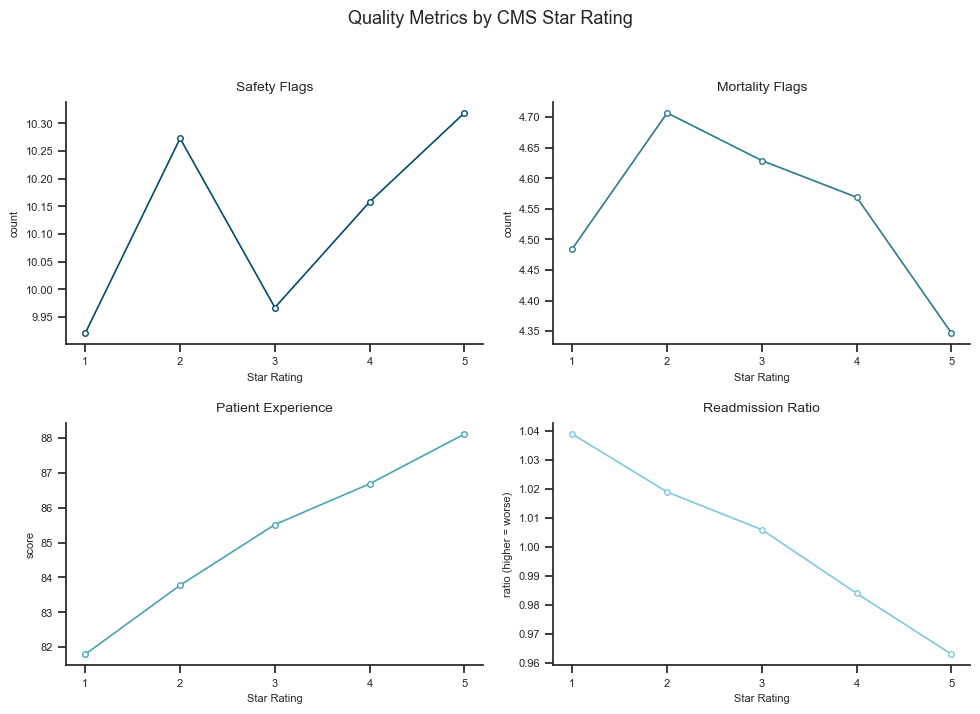

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1.2})

star_plot = star_profile.reset_index()

star_plot['hospital_overall_rating'] = star_plot['hospital_overall_rating'].astype(int)

colors = ['#004c6d', '#2c7a8c', '#4aa3b5', '#7ec8e0']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Quality Metrics by CMS Star Rating', fontsize=13, fontweight='normal', y=1.02)

metrics = [
    ('whatever_flags_safe', 'Safety Flags', colors[0], 'count'),
    ('whatever_flags_mort', 'Mortality Flags', colors[1], 'count'),
    ('patient_exp_score', 'Patient Experience', colors[2], 'score'),
    ('readm_ratio_avg', 'Readmission Ratio', colors[3], 'ratio (higher = worse)')
]

for ax, (col, title, color, ylabel) in zip(axes.flat, metrics):
    ax.plot(star_plot['hospital_overall_rating'], star_plot[col],
            marker='o', markersize=4, linewidth=1.2, color=color,
            markerfacecolor='white', markeredgewidth=1, markeredgecolor=color)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel('Star Rating', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    
    ax.set_xticks([1, 2, 3, 4, 5])
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    #ax.grid(axis='y', linestyle='-', alpha=0.15)
    sns.set_style("white")
plt.tight_layout()
plt.show()

##### AS Expected , safety measures and mortality measures are NOT clear it combines BETTER / WORSE / NOT DIFFRENT than the national average. 
What to do ? 
In this case i will seperate each flag within each measure , and merge all keeping the patient experience scores and readmission ratio all the same , but then we figure out how to plot them. 


In [13]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_mort_measures = [
    'comp_flag_mort_30_ami', 'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd',
    'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 'comp_flag_mort_30_stk'
]

for col in flag_list_mort_measures:
    complications[col] = complications[col].astype(str)

better_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('better' in cell.lower() for cell in row),
    axis=1
)

worse_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('worse' in cell.lower() for cell in row),
    axis=1
)
not_diff_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('no different' in cell.lower() for cell in row),
    axis=1
)

flag_df_mort = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'better_flags_mort': better_counts,
    'worse_flags_mort': worse_counts,
    'not_different_mort' : not_diff_counts
})

complications_mort_measures = (
    flag_df_mort
    #.sort_values('better_flags_mort', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

complications_mort_measures[['facility_id', 'facility_name', 'state', 'hospital_type', 'better_flags_mort', 'worse_flags_mort','not_different_mort']]


,facility_id,facility_name,state,hospital_type,better_flags_mort,worse_flags_mort,not_different_mort
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,0,0,6
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,0,1,3
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,0,2,4
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,0,1,2
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,0,0,1
5,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,0,0,6
6,010012,DEKALB REGIONAL MEDICAL CENTER,AL,Acute Care Hospitals,0,0,4
7,010016,SHELBY BAPTIST MEDICAL CENTER,AL,Acute Care Hospitals,0,0,6
8,010018,CALLAHAN EYE HOSPITAL,AL,Acute Care Hospitals,0,0,0
9,010019,HELEN KELLER HOSPITAL,AL,Acute Care Hospitals,0,1,3


In [14]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_safe_measures = ['comp_flag_psi_03', 'comp_flag_psi_04', 'comp_flag_psi_06', 
             'comp_flag_psi_08', 'comp_flag_psi_09', 'comp_flag_psi_10','comp_flag_psi_11',
                 'comp_flag_psi_12','comp_flag_psi_13','comp_flag_psi_14','comp_flag_psi_15','comp_flag_psi_90']

for col in flag_list_safe_measures:
    complications[col] = complications[col].astype(str)

better_counts = complications[flag_list_safe_measures].apply(
    lambda row: sum('better' in cell.lower() for cell in row),
    axis=1
)

worse_counts = complications[flag_list_safe_measures].apply(
    lambda row: sum('worse' in cell.lower() for cell in row),
    axis=1
)
not_diff_counts = complications[flag_list_safe_measures].apply(
    lambda row: sum('no different' in cell.lower() for cell in row),
    axis=1
)

flag_df_safe = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'better_flags_safety': better_counts,
    'worse_flags_safety': worse_counts,
    'not_different_safety' : not_diff_counts
})

complications_safety_measures = (
    flag_df_safe
    #.sort_values('better_flags_mort', ascending=False)
    .reset_index(drop=True)
    .head(10)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

complications_safety_measures[['facility_id', 'facility_name', 'state', 'hospital_type', 'better_flags_safety', 'worse_flags_safety','not_different_safety']]


,facility_id,facility_name,state,hospital_type,better_flags_safety,worse_flags_safety,not_different_safety
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,0,1,11
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,0,0,12
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,0,2,10
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,0,0,9
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,0,0,3
5,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,0,0,12
6,010012,DEKALB REGIONAL MEDICAL CENTER,AL,Acute Care Hospitals,0,0,11
7,010016,SHELBY BAPTIST MEDICAL CENTER,AL,Acute Care Hospitals,0,2,10
8,010018,CALLAHAN EYE HOSPITAL,AL,Acute Care Hospitals,0,0,5
9,010019,HELEN KELLER HOSPITAL,AL,Acute Care Hospitals,0,0,8


In [15]:
for df in [general_info,flag_df_safe, flag_df_mort]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

all_flags = general_info[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_overall_rating'
]].copy()

all_flags = all_flags.merge(
    flag_df_safe[['facility_id', 'better_flags_safety','worse_flags_safety','not_different_safety']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    flag_df_mort[['facility_id', 'better_flags_mort', 'worse_flags_mort','not_different_mort']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    better_df_experience[['facility_id', 'patient_exp_score']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    better_df_readmissions[['facility_id', 'readm_ratio_avg']],
    on='facility_id', how='left'
)
all_flags.head(10)


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,better_flags_safety,worse_flags_safety,not_different_safety,better_flags_mort,worse_flags_mort,not_different_mort,patient_exp_score,readm_ratio_avg
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,4.0,0.0,1.0,11.0,0.0,0.0,6.0,87.875,0.978383
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,3.0,0.0,0.0,12.0,0.0,1.0,3.0,85.625,0.918100
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,2.0,0.0,2.0,10.0,0.0,2.0,4.0,82.000,1.000217
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,1.0,0.0,0.0,9.0,0.0,1.0,2.0,86.250,1.039900
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,NaN,0.0,0.0,3.0,0.0,0.0,1.0,NaN,1.001700
5,010011,ST. VINCENT'S EAST,AL,Acute Care Hospitals,2.0,0.0,0.0,12.0,0.0,0.0,6.0,84.875,1.027460
6,010012,DEKALB REGIONAL MEDICAL CENTER,AL,Acute Care Hospitals,3.0,0.0,0.0,11.0,0.0,0.0,4.0,85.000,1.017340
7,010016,SHELBY BAPTIST MEDICAL CENTER,AL,Acute Care Hospitals,2.0,0.0,2.0,10.0,0.0,0.0,6.0,83.500,1.039700
8,010018,CALLAHAN EYE HOSPITAL,AL,Acute Care Hospitals,NaN,0.0,0.0,5.0,0.0,0.0,0.0,NaN,NaN
9,010019,HELEN KELLER HOSPITAL,AL,Acute Care Hospitals,2.0,0.0,0.0,8.0,0.0,1.0,3.0,88.000,1.040325


In [16]:
final_star_profile = (
    all_flags
    .dropna(subset=['hospital_overall_rating'])
    .groupby('hospital_overall_rating')[[
        ##'comp_better_flags',
        ##'hai_better_flags',
        'better_flags_safety','worse_flags_safety','not_different_safety',
        'better_flags_mort', 'worse_flags_mort','not_different_mort',
        'patient_exp_score',
        ##'spending_ratio',
        'readm_ratio_avg'
    ]].mean()
    .round(3)
)

final_star_profile

,better_flags_safety,worse_flags_safety,not_different_safety,better_flags_mort,worse_flags_mort,not_different_mort,patient_exp_score,readm_ratio_avg
hospital_overall_rating,,,,,,,,
1.0,0.009,0.476,9.437,0.079,0.358,4.048,81.798,1.039
2.0,0.031,0.307,9.935,0.091,0.225,4.391,83.777,1.019
3.0,0.056,0.239,9.672,0.218,0.146,4.266,85.518,1.006
4.0,0.084,0.154,9.920,0.331,0.064,4.174,86.690,0.984
5.0,0.344,0.174,9.802,0.882,0.021,3.444,88.116,0.963


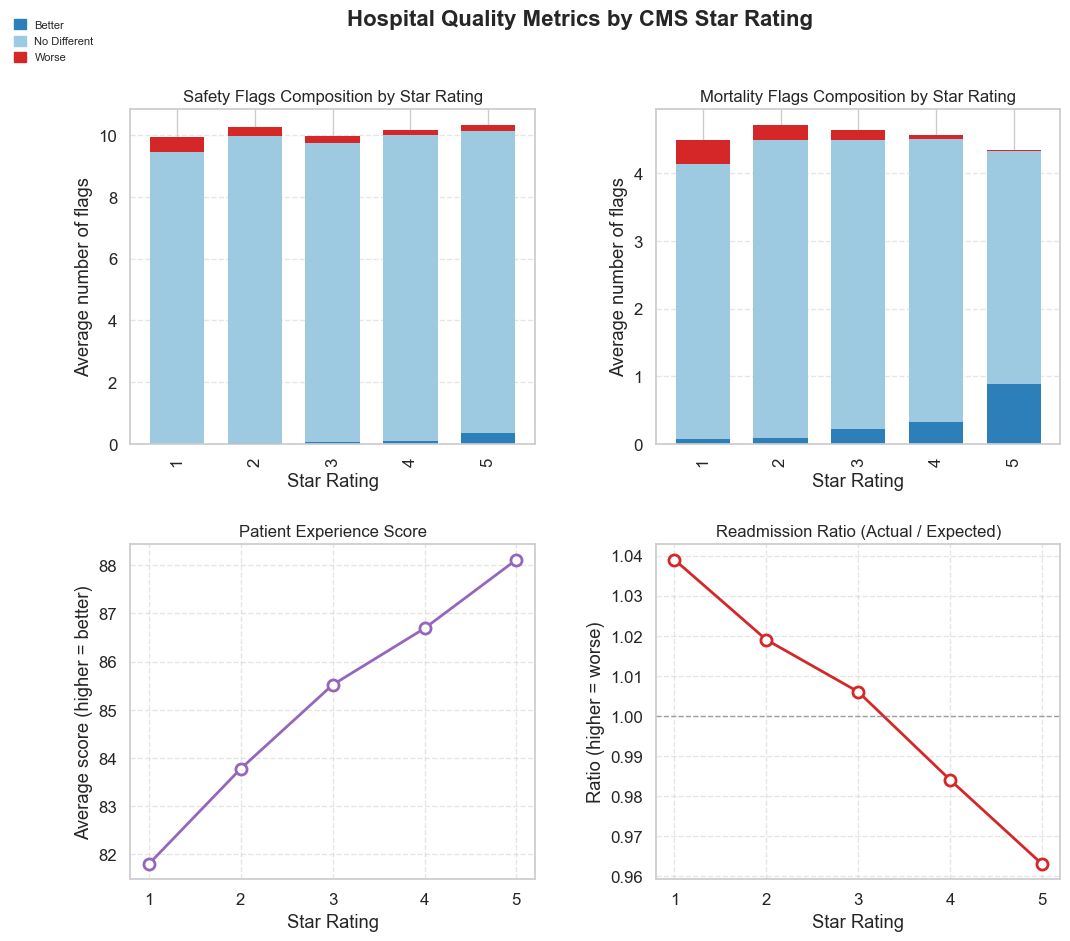

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

star_plot = final_star_profile.reset_index()
star_plot['hospital_overall_rating'] = star_plot['hospital_overall_rating'].astype(int)

sns.set_style("whitegrid")

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
safety_cols = ['better_flags_safety', 'not_different_safety', 'worse_flags_safety']
safety_data = star_plot.set_index('hospital_overall_rating')[safety_cols]
safety_data.plot(kind='bar', stacked=True, ax=ax1, color=['#2c7fb8', '#9ecae1', '#d62728'], 
                 edgecolor='none', width=0.7, legend=False)
ax1.set_title('Safety Flags Composition by Star Rating', fontsize=12)
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Average number of flags')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(gs[0, 1])
mort_cols = ['better_flags_mort', 'not_different_mort', 'worse_flags_mort']
mort_data = star_plot.set_index('hospital_overall_rating')[mort_cols]
mort_data.plot(kind='bar', stacked=True, ax=ax2, color=['#2c7fb8', '#9ecae1', '#d62728'],
               edgecolor='none', width=0.7, legend=False)
ax2.set_title('Mortality Flags Composition by Star Rating', fontsize=12)
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Average number of flags')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(star_plot['hospital_overall_rating'], star_plot['patient_exp_score'], 
         marker='o', linewidth=2, color='#9467bd', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax3.set_title('Patient Experience Score', fontsize=12)
ax3.set_xlabel('Star Rating')
ax3.set_ylabel('Average score (higher = better)')
ax3.set_xticks([1,2,3,4,5])
ax3.grid(True, linestyle='--', alpha=0.5)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(star_plot['hospital_overall_rating'], star_plot['readm_ratio_avg'], 
         marker='o', linewidth=2, color='#d62728', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax4.set_title('Readmission Ratio (Actual / Expected)', fontsize=12)
ax4.set_xlabel('Star Rating')
ax4.set_ylabel('Ratio (higher = worse)')
ax4.set_xticks([1,2,3,4,5])
ax4.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax4.grid(True, linestyle='--', alpha=0.5)

handles = [plt.Rectangle((0,0),1,1, color='#2c7fb8'),
           plt.Rectangle((0,0),1,1, color='#9ecae1'),
           plt.Rectangle((0,0),1,1, color='#d62728')]
labels = ['Better', 'No Different', 'Worse']
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.02, 0.98),
           fontsize=8, frameon=False, ncol=1, handlelength=1, handleheight=1)

fig.suptitle('Hospital Quality Metrics by CMS Star Rating', fontsize=16, weight='semibold', y=0.98)

plt.savefig('hosp_quality_star_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### AND WITH THAT THE Q2 IS FULLY ANSWERED 
#### The plot explains itself , a 5 star hospital is doing great in every measure , they are the best acording to patient experience , the best at readmission ratio , they are doing better than national average considering mortality rates and quite better when it comes to safety measures. 
The Red color that appears in the top of the 5 star hospitals is due to something else , it's a good idea to investigate it but it is enough to say it is a range where patients experience a bad treatment or distany took their life even when doctors did what it should be done. 
##### DID WE ANSWER THE QUESTION? How aligned is the CMS star rating with actual clinical outcomes?
*Yes by going up to 5 stared hospitals, they have low readmission ratio, high score parient experince , they are slightly doing better than the national rate when it comes to mortality rates and safety measures.* 


In [19]:
# Create a master table that has the ID and the scores
hospital_clinical_master = all_flags[[
    'facility_id', 
    'hospital_overall_rating',
    'better_flags_safety', 
    'worse_flags_safety',
    'better_flags_mort', 
    'worse_flags_mort',
    'readm_ratio_avg',
    'patient_exp_score'
]]

hospital_clinical_master.to_csv('PBI1_hospital_clinical_data.csv', index=False)
print('saved')

saved
